In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, Normalizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, log_loss, cohen_kappa_score
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import PartialDependenceDisplay
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

from catboost import CatBoostClassifier

import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv('D:\study\semster 2 year 3\XAI\XAI github\cardiovascular_fe.csv')
df.head()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,BMI,PULSE_PRESSURE,MAP,RISK_SCORE,METABOLIC_RISK,AGE_BP_RISK
0,50,2,168,62,110,80,1,1,0,0,1,0,21.967120,30,90.000000,50,2,5500
1,55,1,156,85,140,90,3,1,0,0,1,1,34.927679,50,106.666667,165,4,7700
2,52,1,165,64,130,70,3,1,0,0,0,1,23.507805,60,90.000000,156,4,6760
3,48,2,169,82,150,100,1,1,0,0,1,1,28.710479,50,116.666667,48,2,7200
4,60,1,151,67,120,80,2,2,0,0,0,0,29.384676,40,93.333333,120,4,7200


In [39]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 62513 entries, 0 to 62512
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   AGE                62513 non-null  int64  
 1   GENDER             62513 non-null  int64  
 2   HEIGHT             62513 non-null  int64  
 3   WEIGHT             62513 non-null  int64  
 4   AP_HIGH            62513 non-null  int64  
 5   AP_LOW             62513 non-null  int64  
 6   CHOLESTEROL        62513 non-null  int64  
 7   GLUCOSE            62513 non-null  int64  
 8   SMOKE              62513 non-null  int64  
 9   ALCOHOL            62513 non-null  int64  
 10  PHYSICAL_ACTIVITY  62513 non-null  int64  
 11  CARDIO_DISEASE     62513 non-null  int64  
 12  BMI                62513 non-null  float64
 13  PULSE_PRESSURE     62513 non-null  int64  
 14  MAP                62513 non-null  float64
 15  RISK_SCORE         62513 non-null  int64  
 16  METABOLIC_RISK     62513 non-null

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,BMI,PULSE_PRESSURE,MAP,RISK_SCORE,METABOLIC_RISK,AGE_BP_RISK
count,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000,62513.000000
mean,53.406028,1.348583,164.405964,73.180474,126.419609,81.698367,1.357686,1.220610,0.086334,0.052165,0.804313,0.493881,27.119944,44.721242,96.605447,73.211412,2.578296,6771.354806
std,6.742440,0.476526,7.531095,12.272424,14.290546,7.673384,0.675167,0.567559,0.280859,0.222362,0.396732,0.499967,4.567853,10.409748,9.123951,39.917202,1.059672,1257.682992
min,30.000000,1.000000,143.000000,40.000000,90.000000,65.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,13.520822,-10.000000,73.333333,30.000000,2.000000,3300.000000
25%,49.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115,40.000000,93.333333,50.000000,2.000000,5880.000000
50%,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.233556,40.000000,93.333333,56.000000,2.000000,6720.000000
75%,58.000000,2.000000,170.000000,81.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,29.760838,50.000000,103.333333,64.000000,3.000000,7560.000000
max,65.000000,2.000000,186.000000,107.000000,170.000000,105.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,50.891795,103.000000,126.000000,195.000000,6.000000,11050.000000


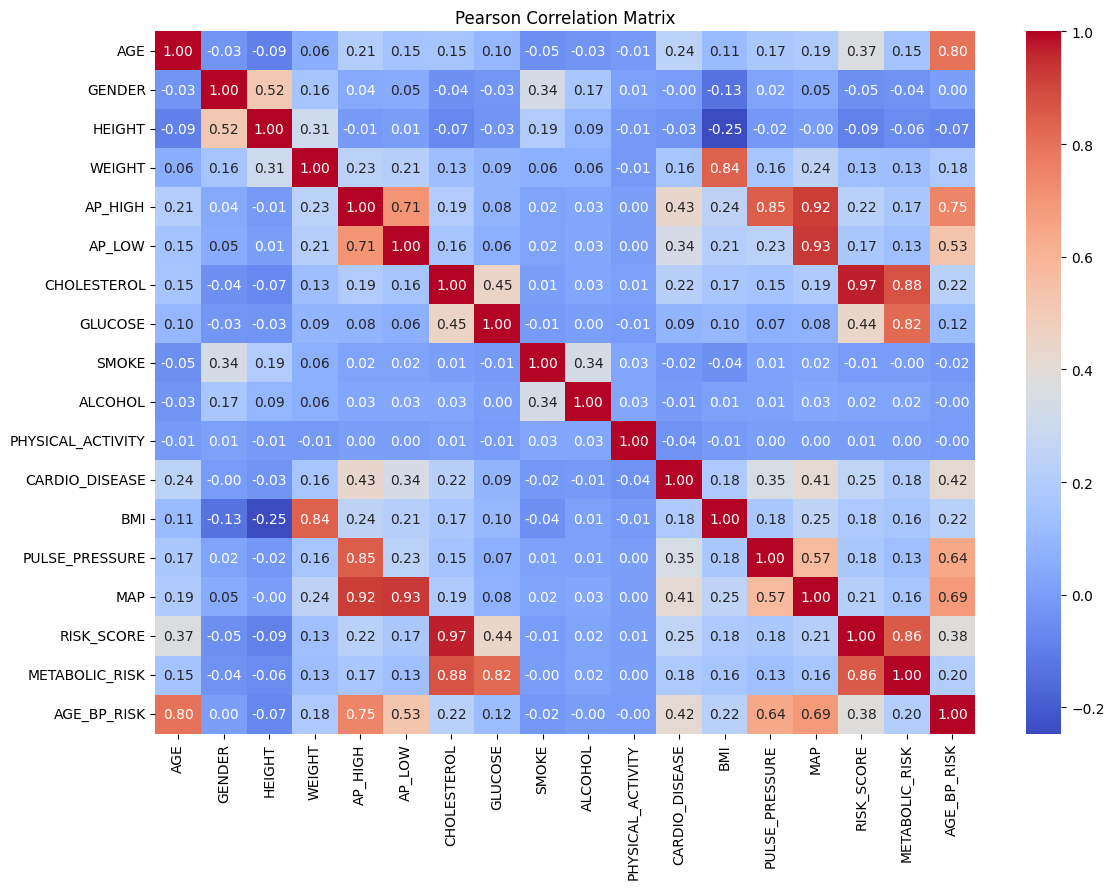

In [40]:
# Pearson correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

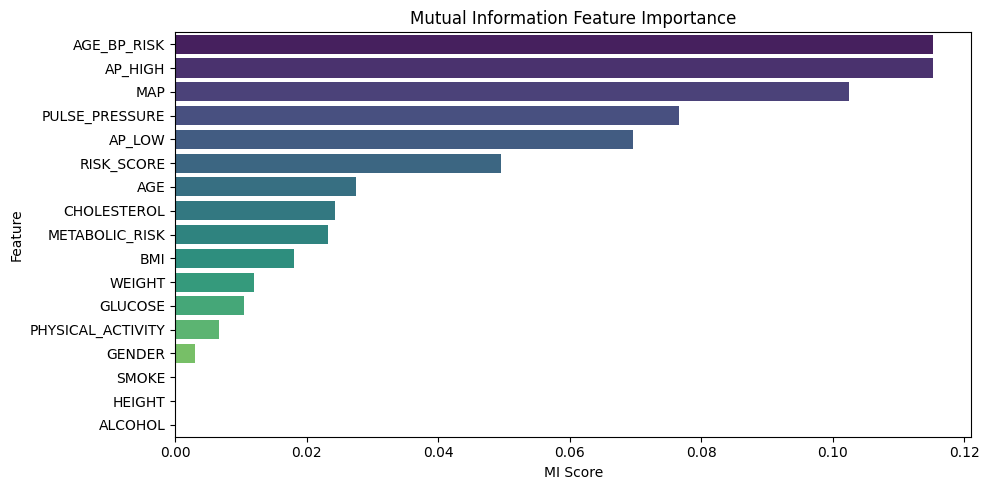

In [43]:
# Mutual Information feature importance
X= df.drop('CARDIO_DISEASE', axis=1)
y = df['CARDIO_DISEASE']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores}).sort_values('MI Score', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=mi_df, x='MI Score', y='Feature', palette='viridis')
plt.title('Mutual Information Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [45]:
# Min-Max scaling (best for GBM per paper)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

feature_names = list(X.columns)

In [46]:
# ---- MODEL 1: Gradient Boosting Machine (GBM) ----
gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gbm.fit(X_train_scaled, y_train)
y_pred_gbm = gbm.predict(X_test_scaled)
y_prob_gbm = gbm.predict_proba(X_test_scaled)

In [47]:
print('=== GBM Results ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_gbm):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_gbm):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_gbm):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_gbm):.4f}')
print(f'AUC      : {roc_auc_score(y_test, y_prob_gbm[:,1]):.4f}')
print(f"Cohen's K: {cohen_kappa_score(y_test, y_pred_gbm):.4f}")
print(f'Log Loss : {log_loss(y_test, y_prob_gbm):.4f}')
print(classification_report(y_test, y_pred_gbm))

=== GBM Results ===
Accuracy : 0.7258
Precision: 0.7469
Recall   : 0.6729
F1 Score : 0.7080
AUC      : 0.7916
Cohen's K: 0.4509
Log Loss : 0.5525
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6328
           1       0.75      0.67      0.71      6175

    accuracy                           0.73     12503
   macro avg       0.73      0.73      0.72     12503
weighted avg       0.73      0.73      0.73     12503



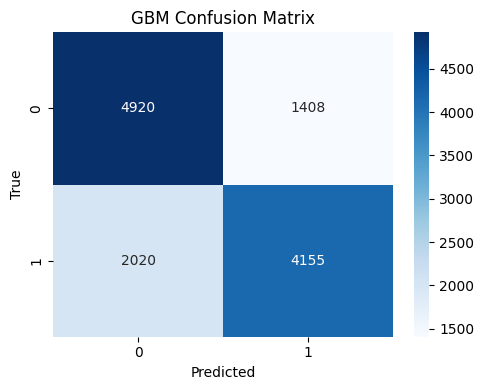

In [48]:
cm_gbm = confusion_matrix(y_test, y_pred_gbm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_gbm, annot=True, fmt='d', cmap='Blues')
plt.title('GBM Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [49]:
# ---- MODEL 2: CatBoost ----
cb = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=0)
cb.fit(X_train_scaled, y_train)
y_pred_cb = cb.predict(X_test_scaled)
y_prob_cb = cb.predict_proba(X_test_scaled)

In [50]:
print('=== CatBoost Results ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_cb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_cb):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_cb):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_cb):.4f}')
print(f'AUC      : {roc_auc_score(y_test, y_prob_cb[:,1]):.4f}')
print(f"Cohen's K: {cohen_kappa_score(y_test, y_pred_cb):.4f}")
print(f'Log Loss : {log_loss(y_test, y_prob_cb):.4f}')
print(classification_report(y_test, y_pred_cb))

=== CatBoost Results ===
Accuracy : 0.7271
Precision: 0.7487
Recall   : 0.6735
F1 Score : 0.7091
AUC      : 0.7917
Cohen's K: 0.4535
Log Loss : 0.5520
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6328
           1       0.75      0.67      0.71      6175

    accuracy                           0.73     12503
   macro avg       0.73      0.73      0.73     12503
weighted avg       0.73      0.73      0.73     12503



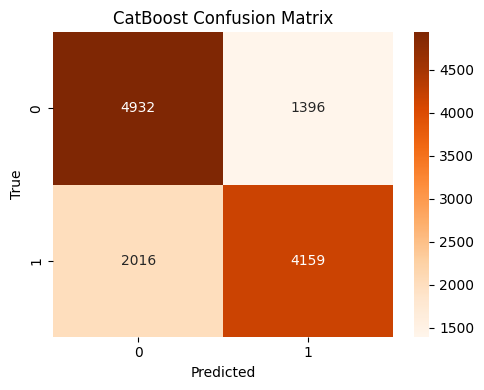

In [51]:
cm_cb = confusion_matrix(y_test, y_pred_cb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_cb, annot=True, fmt='d', cmap='Oranges')
plt.title('CatBoost Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

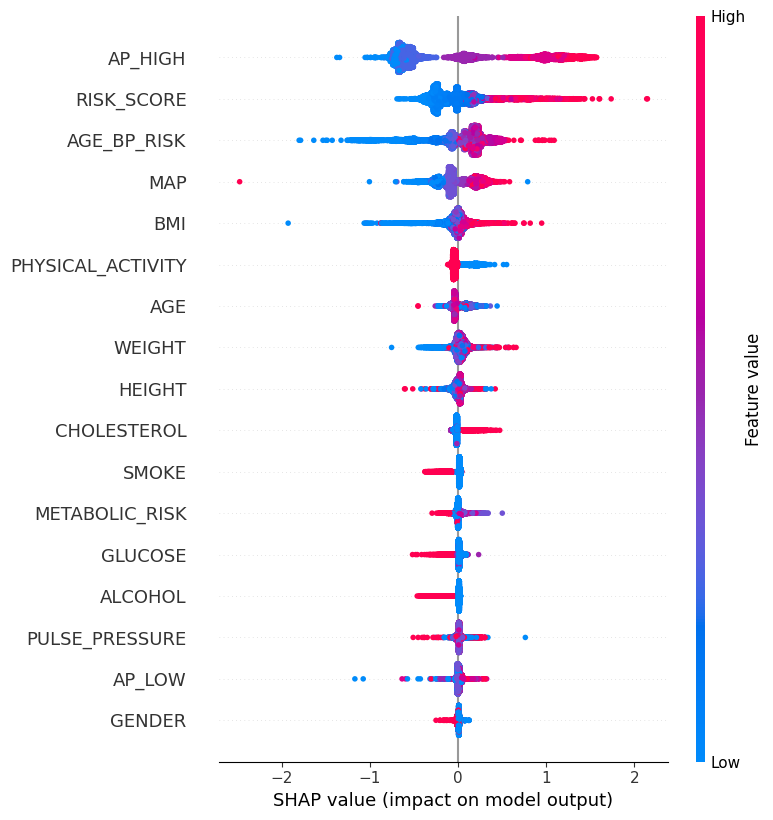

In [52]:
# ============================================================
# EXPLAINABILITY - GBM
# ============================================================

# 1) SHAP - GBM
explainer_gbm = shap.TreeExplainer(gbm)
shap_values_gbm = explainer_gbm.shap_values(X_test_scaled)

shap.summary_plot(shap_values_gbm, X_test_scaled, feature_names=feature_names, show=True)

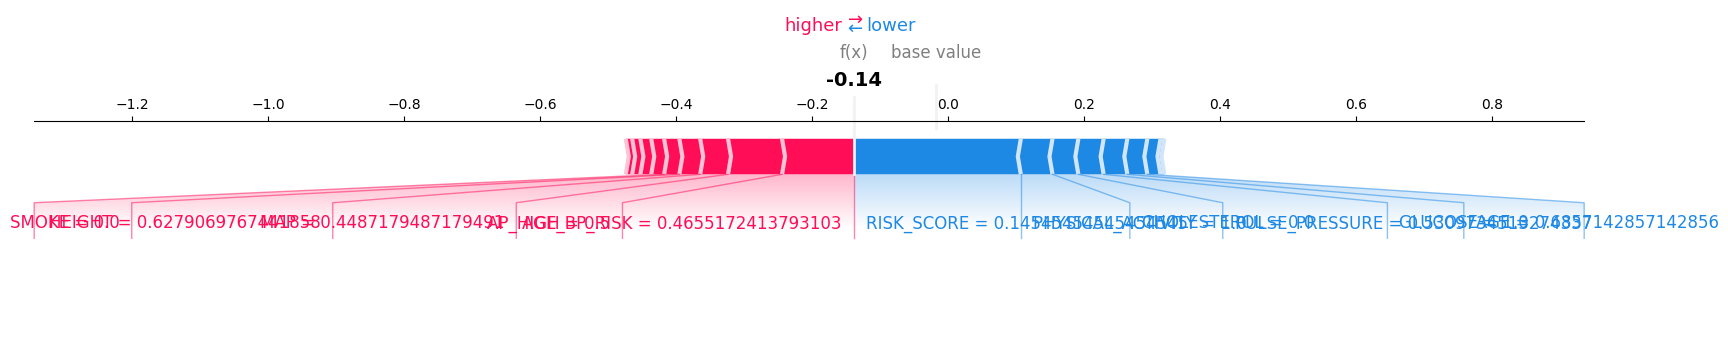

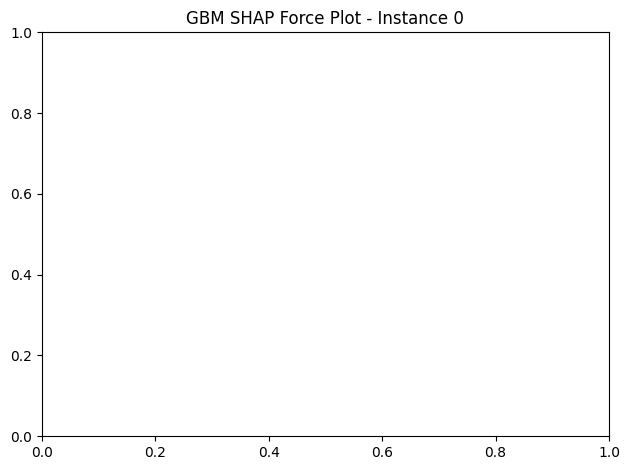

In [53]:
shap.force_plot(
    explainer_gbm.expected_value,
    shap_values_gbm[0],
    X_test_scaled[0],
    feature_names=feature_names,
    matplotlib=True
)
plt.title('GBM SHAP Force Plot - Instance 0')
plt.tight_layout()
plt.show()

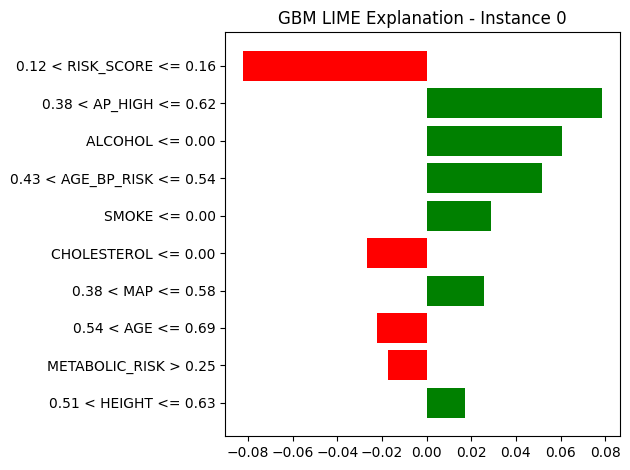

In [54]:
# 2) LIME - GBM
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=feature_names,
    class_names=['No Disease', 'Disease'],
    mode='classification',
    random_state=42
)

lime_exp_gbm = lime_explainer.explain_instance(X_test_scaled[0], gbm.predict_proba, num_features=10)
lime_exp_gbm.as_pyplot_figure()
plt.title('GBM LIME Explanation - Instance 0')
plt.tight_layout()
plt.show()

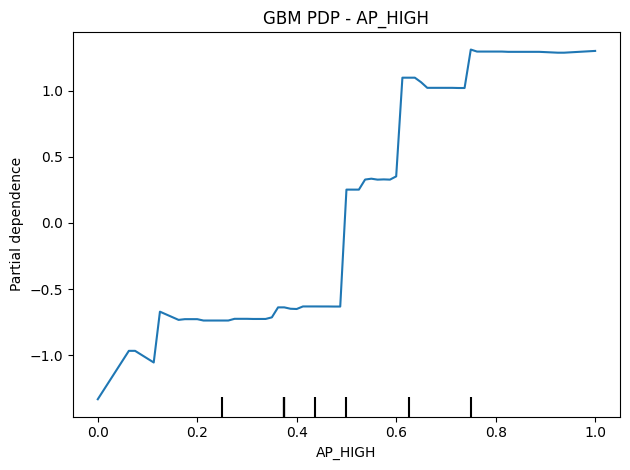

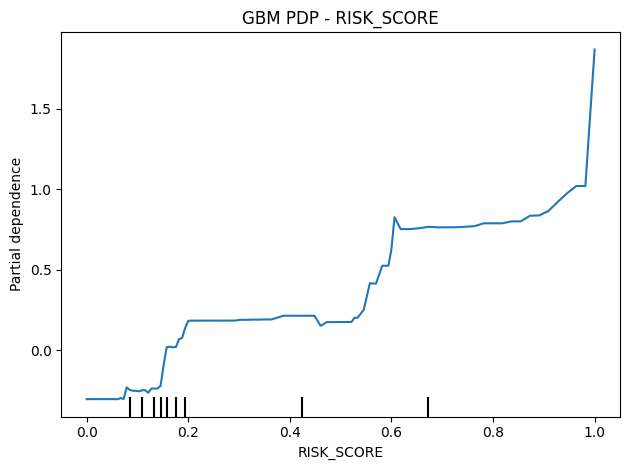

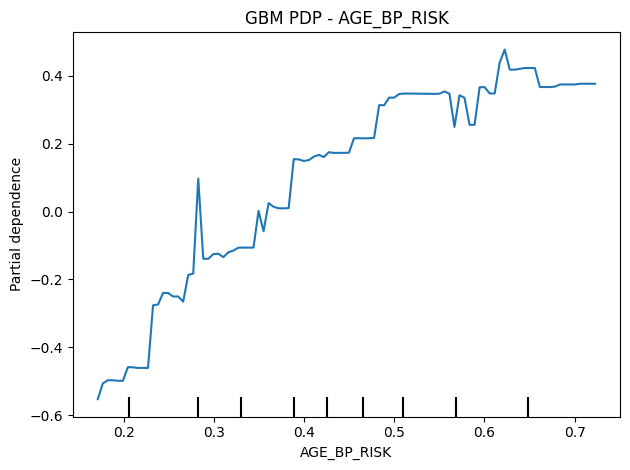

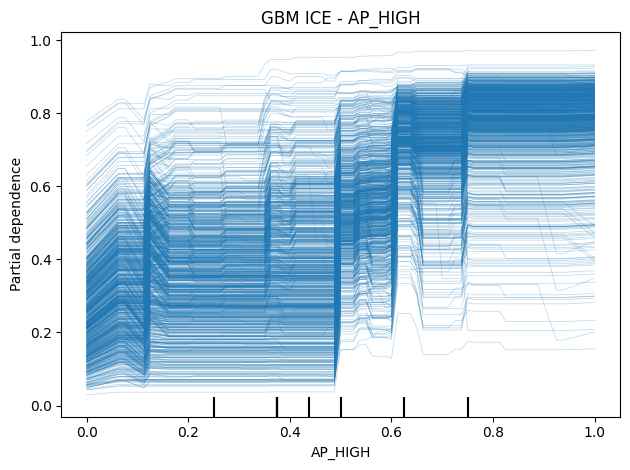

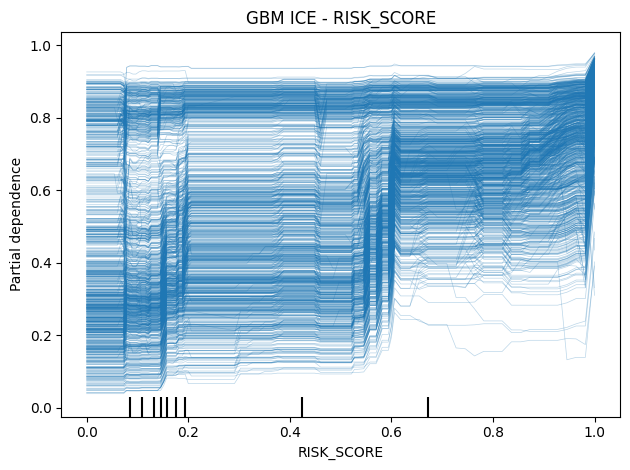

In [55]:
# 3) PDP / ICE - GBM
top_gbm_features = pd.Series(gbm.feature_importances_, index=feature_names).nlargest(3).index.tolist()
top_gbm_idx = [feature_names.index(f) for f in top_gbm_features]

for idx, feat in zip(top_gbm_idx, top_gbm_features):
    PartialDependenceDisplay.from_estimator(gbm, X_test_scaled, [idx], feature_names=feature_names, kind='average')
    plt.title(f'GBM PDP - {feat}')
    plt.tight_layout()
    plt.show()

for idx, feat in zip(top_gbm_idx[:2], top_gbm_features[:2]):
    PartialDependenceDisplay.from_estimator(gbm, X_test_scaled, [idx], feature_names=feature_names, kind='individual')
    plt.title(f'GBM ICE - {feat}')
    plt.tight_layout()
    plt.show()

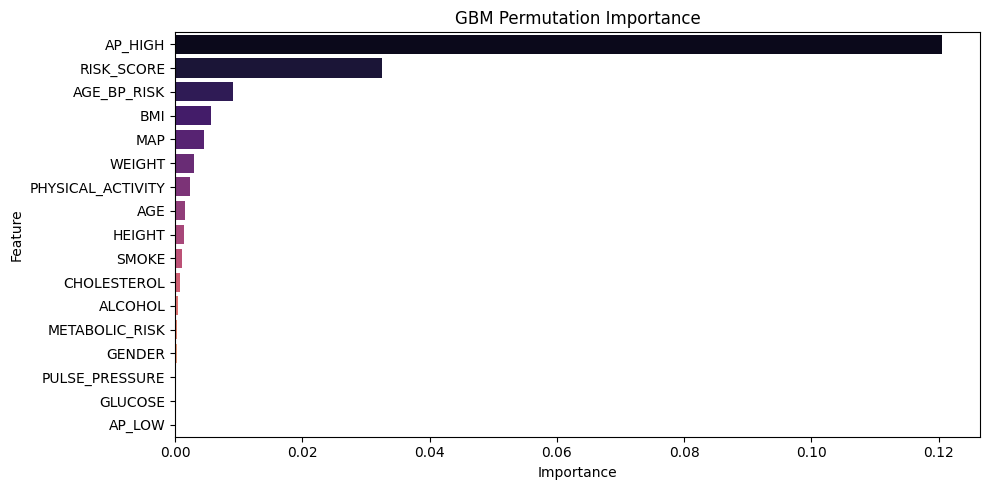

In [56]:
# 4) Permutation Importance - GBM
from sklearn.inspection import permutation_importance

perm_gbm = permutation_importance(gbm, X_test_scaled, y_test, n_repeats=10, random_state=42, scoring='accuracy')
perm_gbm_df = pd.DataFrame({'Feature': feature_names, 'Importance': perm_gbm.importances_mean}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=perm_gbm_df, x='Importance', y='Feature', palette='magma')
plt.title('GBM Permutation Importance')
plt.tight_layout()
plt.show()

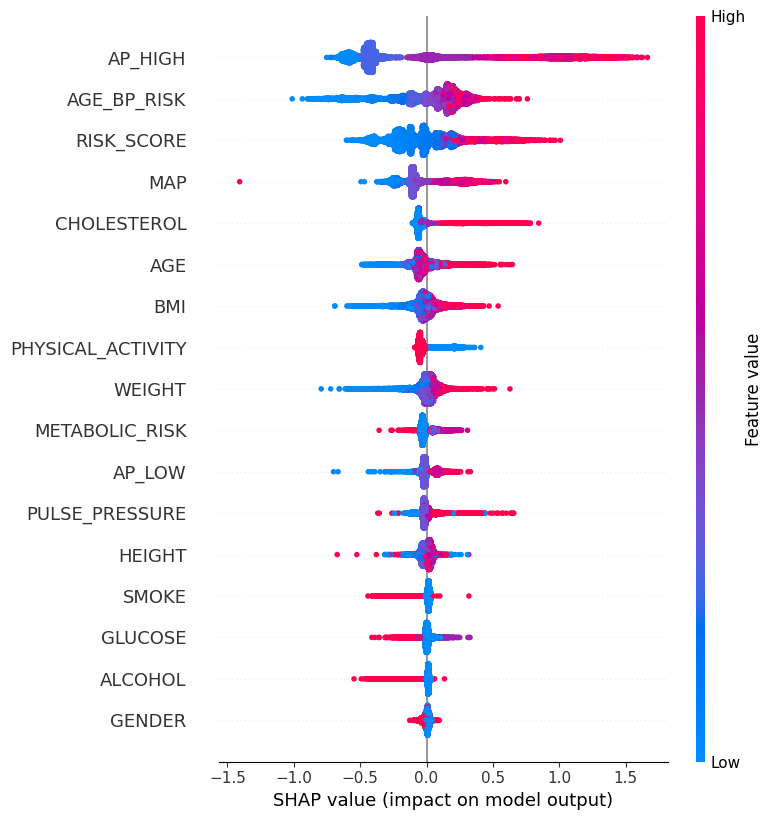

In [57]:
# ============================================================
# EXPLAINABILITY - CatBoost
# ============================================================

# 1) SHAP - CatBoost
explainer_cb = shap.TreeExplainer(cb)
shap_values_cb = explainer_cb.shap_values(X_test_scaled)

shap.summary_plot(shap_values_cb, X_test_scaled, feature_names=feature_names, show=True)

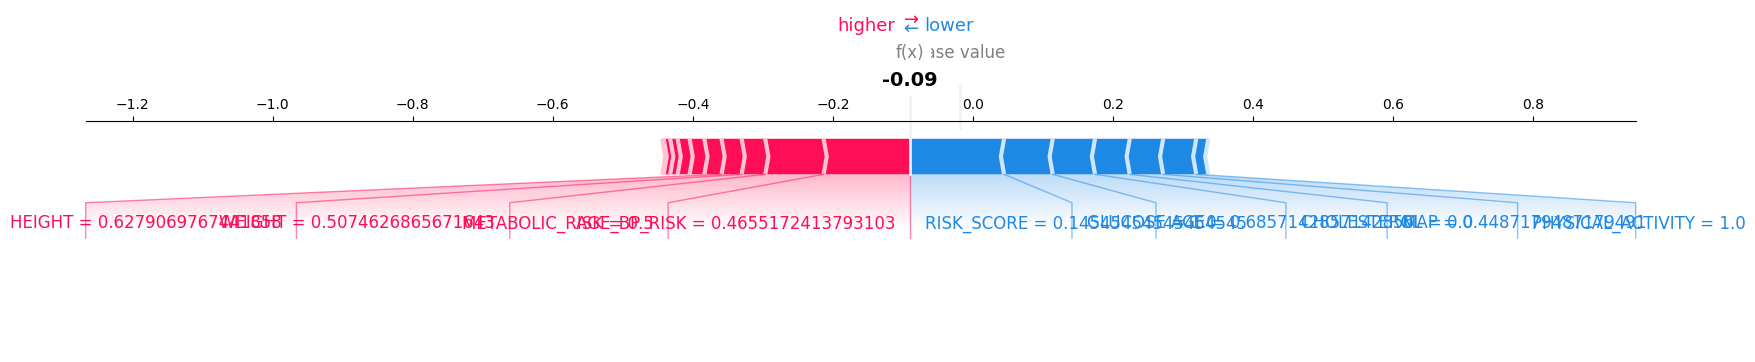

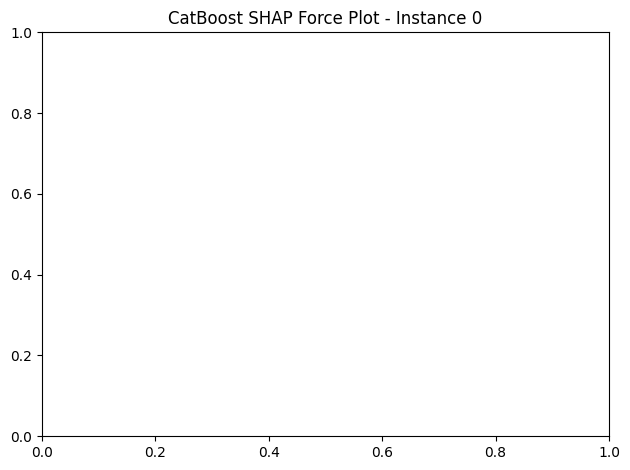

In [58]:
shap.force_plot(
    explainer_cb.expected_value,
    shap_values_cb[0],
    X_test_scaled[0],
    feature_names=feature_names,
    matplotlib=True
)
plt.title('CatBoost SHAP Force Plot - Instance 0')
plt.tight_layout()
plt.show()

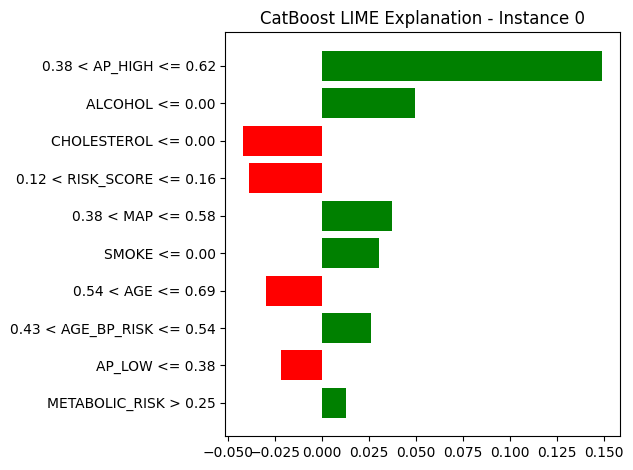

In [59]:
# 2) LIME - CatBoost
lime_exp_cb = lime_explainer.explain_instance(X_test_scaled[0], cb.predict_proba, num_features=10)
lime_exp_cb.as_pyplot_figure()
plt.title('CatBoost LIME Explanation - Instance 0')
plt.tight_layout()
plt.show()

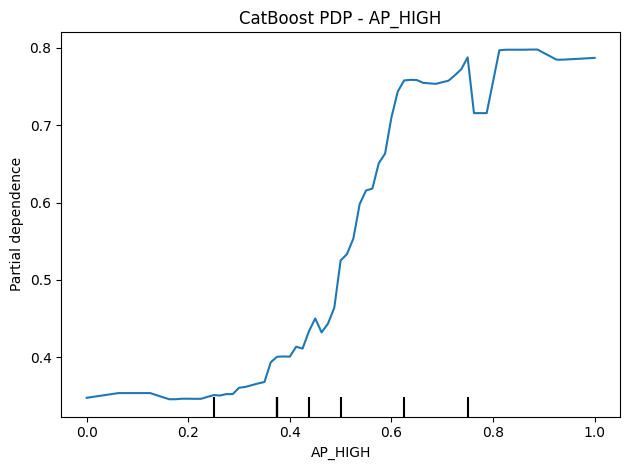

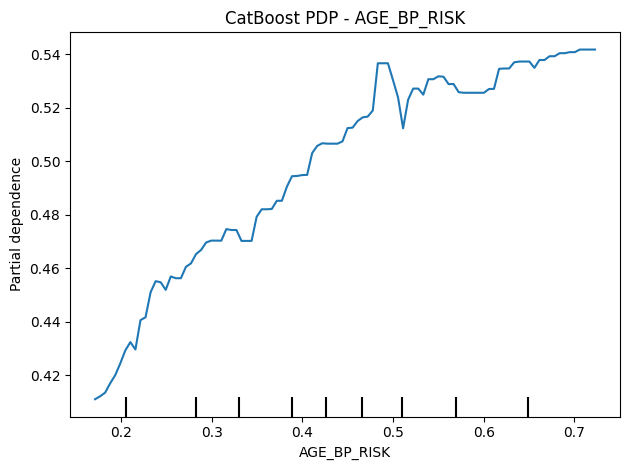

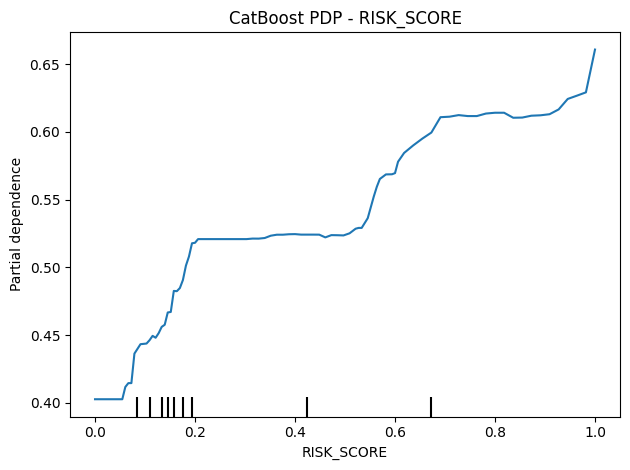

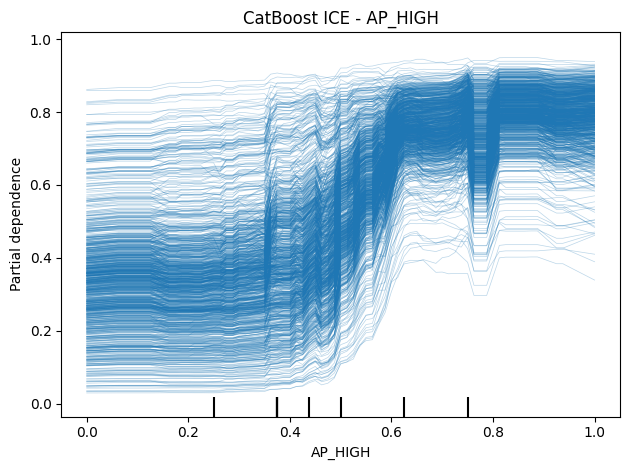

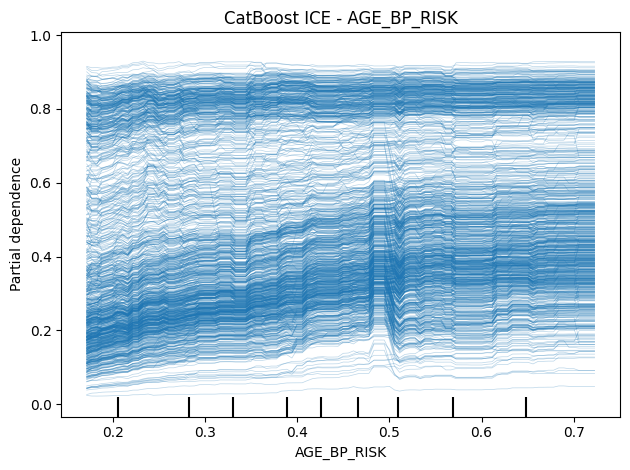

In [60]:
# 3) PDP / ICE - CatBoost
cb_fi = pd.Series(cb.get_feature_importance(), index=feature_names)
top_cb_features = cb_fi.nlargest(3).index.tolist()
top_cb_idx = [feature_names.index(f) for f in top_cb_features]

for idx, feat in zip(top_cb_idx, top_cb_features):
    PartialDependenceDisplay.from_estimator(cb, X_test_scaled, [idx], feature_names=feature_names, kind='average')
    plt.title(f'CatBoost PDP - {feat}')
    plt.tight_layout()
    plt.show()

for idx, feat in zip(top_cb_idx[:2], top_cb_features[:2]):
    PartialDependenceDisplay.from_estimator(cb, X_test_scaled, [idx], feature_names=feature_names, kind='individual')
    plt.title(f'CatBoost ICE - {feat}')
    plt.tight_layout()
    plt.show()

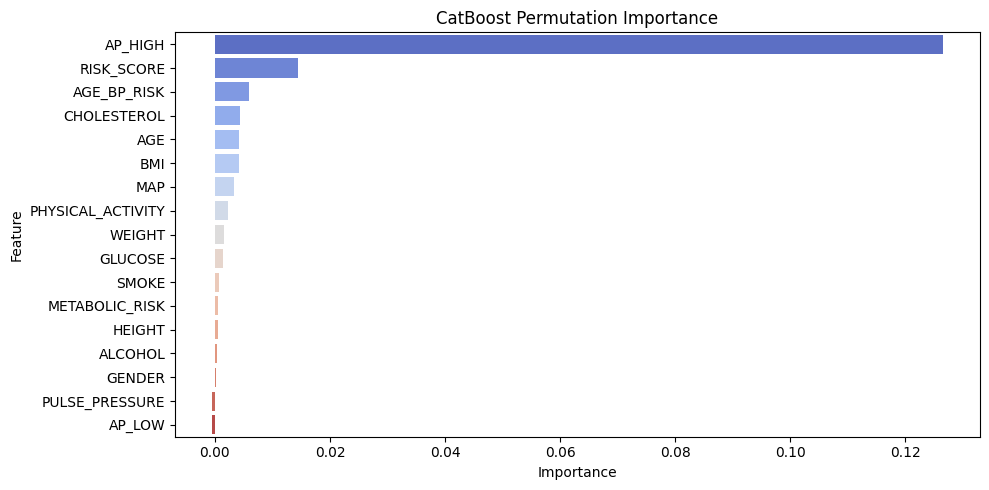

In [61]:
# 4) Permutation Importance - CatBoost
perm_cb = permutation_importance(cb, X_test_scaled, y_test, n_repeats=10, random_state=42, scoring='accuracy')
perm_cb_df = pd.DataFrame({'Feature': feature_names, 'Importance': perm_cb.importances_mean}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=perm_cb_df, x='Importance', y='Feature', palette='coolwarm')
plt.title('CatBoost Permutation Importance')
plt.tight_layout()
plt.show()

In [62]:
# Final comparison table
results = pd.DataFrame({
    'Model'    : ['GBM', 'CatBoost'],
    'Accuracy' : [accuracy_score(y_test, y_pred_gbm), accuracy_score(y_test, y_pred_cb)],
    'Precision': [precision_score(y_test, y_pred_gbm), precision_score(y_test, y_pred_cb)],
    'Recall'   : [recall_score(y_test, y_pred_gbm), recall_score(y_test, y_pred_cb)],
    'F1'       : [f1_score(y_test, y_pred_gbm), f1_score(y_test, y_pred_cb)],
    'AUC'      : [roc_auc_score(y_test, y_prob_gbm[:,1]), roc_auc_score(y_test, y_prob_cb[:,1])],
    "Cohen's K": [cohen_kappa_score(y_test, y_pred_gbm), cohen_kappa_score(y_test, y_pred_cb)],
    'Log Loss' : [log_loss(y_test, y_prob_gbm), log_loss(y_test, y_prob_cb)]
})
print(results.to_string(index=False))

   Model  Accuracy  Precision   Recall       F1      AUC  Cohen's K  Log Loss
     GBM  0.725826   0.746899 0.672874 0.707957 0.791611   0.450912  0.552503
CatBoost  0.727105   0.748695 0.673522 0.709122 0.791740   0.453466  0.551969
